# Energy barrier and minimum energy path
  
  This notebook computes the energy barrier between two cluster configurations
  using the **string method** (zero-temperature string method / nudged elastic band).
  
  The string method finds the minimum energy path (MEP) connecting two
  configurations $\mathbf{q}_0$ and $\mathbf{q}_1$ in configuration space.
  Along the MEP, the gradient of the energy is everywhere parallel to the path
  (no perpendicular component), so the path represents the most probable
  escape route out of an energy minimum.
  
  The energy barrier is:
  
  $$\Delta E = \max_{s \in [0,1]} E(\mathbf{q}(s)) - E(\mathbf{q}_0)$$
  
  and the **static friction force** is $F_s = \max_s |\nabla_\mathbf{q} E|$ along the MEP —
  the minimum external force required to push the cluster over the barrier.
  
  We cover two cases:
  1. **2D translational MEP**: CM slides at fixed orientation $(x_\text{cm}, y_\text{cm})$
  2. **3D roto-translational MEP**: CM slides *and* cluster rotates $(x_\text{cm}, y_\text{cm}, \theta)$



In [1]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt
from time import time

from flake.substrate import substrate_from_params, calc_matrices_bvect, get_ks
from flake.cluster import rotate, cluster_from_params
from flake.maps import translational_map, rotational_map
from flake.string_method import find_mep
from flake.plot import get_brillouin_zone_2d, plot_BZ2d, plot_UC, plt_cosmetic

## System definition
  
  Tanh-well substrate (triangular lattice) with a nearly-commensurate circular cluster.
  $\rho = 1 + 1/21 \approx 1.048$ introduces a small mismatch; try $\rho = 1$ for
  the fully commensurate case where the barrier is maximum.


In [2]:
rho = 1.0 + 1/21.  # rho=1: commensurate. Try rho=1+1/21 to see barrier drop.
params = {
    # --- SUBSTRATE ---
    'sub_basis': [[0, 0]],
    'b1': [1, 0],
    'b2': [-1./2., sqrt(3.)/2.],
    'epsilon': 1,
    'well_shape': 'tanh',
    'sigma': 0.1, 'a': 0.1, 'b': 0.45, 'wd': 0.25,
    # --- CLUSTER ---
    'a1': list(rho * np.array([1.,   0.])),
    'a2': list(rho * np.array([1./2., -sqrt(3.)/2.])),
    'cl_basis': [[0, 0]],
    'cluster_shape': 'circle',
    'N1': 25, 'N2': 25,
    # theta and pos_cm are initial conditions for dynamics, NOT baked into pos.
    'theta': 0, 'pos_cm': [0, 0.],
}

u, u_inv = calc_matrices_bvect(params['b1'], params['b2'])
S = u_inv.T   # rows are b1, b2 (for plotting)
bz_kw = {'ls': '--', 'color': 'tab:gray', 'lw': 1, 'fill': False}

pen_func, en_func, en_inputs = substrate_from_params(params)

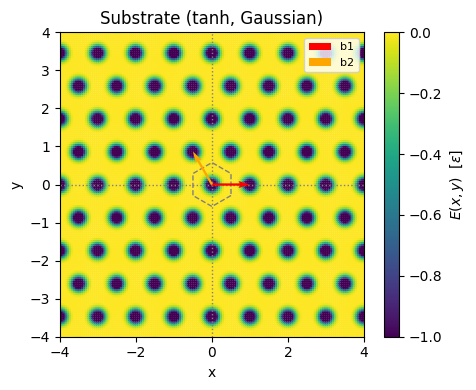

In [3]:
# Single-particle substrate potential on a 2D grid -- sanity check.
x0, x1, nx = -4, 4, 150
y0, y1, ny = -4, 4, 150
xx, yy = np.meshgrid(np.linspace(x0, x1, nx), np.linspace(y0, y1, ny))
p = np.reshape(np.stack([xx, yy], axis=2), (-1, 2))

en, F, tau = pen_func(p, [0, 0], *en_inputs)

fig, ax = plt.subplots(dpi=100, figsize=(5, 4))
sc = ax.scatter(p[:, 0], p[:, 1], c=en, s=1, rasterized=True)
plt.colorbar(sc, label=r'$E(x,y)$  [$\epsilon$]', ax=ax)
plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
ax.quiver(0, 0, *S[0], angles='xy', scale_units='xy', scale=1,
          zorder=5, color='red', label='b1')
ax.quiver(0, 0, *S[1], angles='xy', scale_units='xy', scale=1,
          zorder=5, color='orange', label='b2')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim([x0, x1])
ax.set_ylim([y0, y1])
ax.set_xlabel('x  [a.u.]')
ax.set_ylabel('y  [a.u.]')
ax.set_title('Substrate (%s, Gaussian)' % params['well_shape'])
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

## Cluster

Cluster circle, N=637


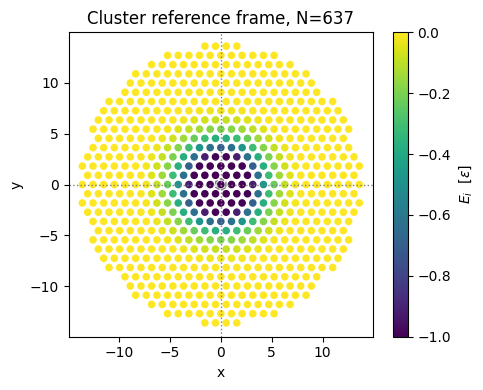

In [4]:
# cluster_from_params returns pos in the REFERENCE FRAME: CM at origin, theta=0.
# theta and pos_cm from params are NOT applied here -- new API convention.
pos = cluster_from_params(params)
N = pos.shape[0]
print('Cluster %s, N=%i' % (params['cluster_shape'], N))

pos_cm_arr = np.asarray(params['pos_cm'])
pen, pF, ptau = pen_func(pos, pos_cm_arr, *en_inputs)

fig, ax = plt.subplots(dpi=100, figsize=(5, 4))
sc = ax.scatter(pos[:, 0], pos[:, 1], c=pen, s=20, vmin=-params['epsilon'], vmax=0)
plt.colorbar(sc, label=r'$E_i$  [$\epsilon$]', ax=ax)
plot_BZ2d(ax, get_brillouin_zone_2d(S), bz_kw)
ax.set_xlabel('x  [a.u.]')
ax.set_ylabel('y  [a.u.]')
ax.set_title('Cluster reference frame, N=%d' % N)
plt_cosmetic(ax)
plt.tight_layout()
plt.show()

## Translational energy landscape
  
  Compute $E(x_\text{cm}, y_\text{cm})$ at fixed orientation $\theta$.
  We pre-rotate `pos` to the desired $\theta$ before calling `translational_map`
  (which treats `pos` as a fixed rigid body). 



In [5]:
pos_rot = rotate(pos, params['theta'])

t0 = time()
map_result = translational_map(
    pos_rot, en_func, en_inputs, u_inv,
    n_x=200, n_y=200,
    frac_x=(-1.5, 1.5), frac_y=(-1.5, 1.5),
)
te = time() - t0
print('Map done: %is (%.2fmin)' % (te, te/60))

pp     = map_result['pos_cm']
enmap  = map_result['energy']
Fmap   = map_result['force']
taumap = map_result['torque']

# Reshape to 2D for contour plotting (n_x == n_y assumed here).
n_grid = int(np.sqrt(pp.shape[0]))
xx_g = pp[:, 0].reshape(n_grid, n_grid)
yy_g = pp[:, 1].reshape(n_grid, n_grid)
zz_g = enmap.reshape(n_grid, n_grid)

Map done: 2s (0.05min)


## 2D translational MEP
  
  `find_mep` with `dim=2` finds the MEP in $(x_\text{cm}, y_\text{cm})$ space
  at fixed orientation. The cluster `pos` must be pre-rotated to the desired $\theta$.
  
  The maximum force magnitude along the MEP is the static friction:
  
  $$F_s = \max_{s} \left| -\frac{dE}{d\mathbf{r}_\text{cm}} \right|$$


In [6]:
p0_2d = [0.0, 0.0]
p1_2d = [1.0, 0.0]   # one lattice vector away along x

t0 = time()
mep = find_mep(
    pos_rot, en_func, en_inputs,
    p0=p0_2d, p1=p1_2d,
    n_pt=50, max_steps=3000, dt=1e-4,
    fix_ends=True, tol=1e-8,
)
te = time() - t0
print('String done: %is (%.2fmin)  converged=%s  steps=%i'
      % (te, te/60, mep['converged'], mep['n_steps']))
print('Barrier: %.5g' % mep['barrier'])

pts = mep['points']   # (n_pt, 2): (x_cm, y_cm)
en  = mep['energy']   # (n_pt,)
s   = np.linspace(0, 1, len(pts))

String done: 0s (0.00min)  converged=True  steps=1
Barrier: 48.326


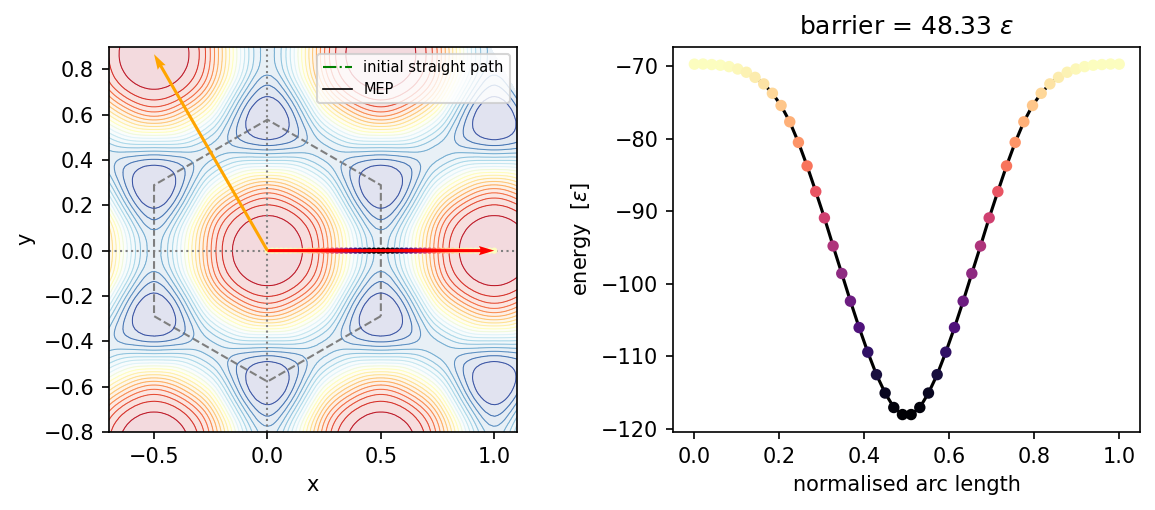

In [7]:
fig, (axE, axpath) = plt.subplots(1, 2, dpi=150, figsize=(8, 3.5))

# Energy landscape with MEP overlaid
axE.contourf(xx_g, yy_g, zz_g, levels=20, cmap='RdYlBu_r', alpha=0.15)
axE.contour( xx_g, yy_g, zz_g, levels=20, cmap='RdYlBu_r', linewidths=0.5)
plot_BZ2d(axE, get_brillouin_zone_2d(S), bz_kw)
axE.quiver(0, 0, *S[0], angles='xy', scale_units='xy', scale=1,
           zorder=5, color='red')
axE.quiver(0, 0, *S[1], angles='xy', scale_units='xy', scale=1,
           zorder=5, color='orange')
axE.plot([p0_2d[0], p1_2d[0]], [p0_2d[1], p1_2d[1]],
         '-.', color='green', lw=1, label='initial straight path', zorder=1)
axE.plot(pts[:, 0], pts[:, 1], '-k', lw=0.8, label='MEP', zorder=2)
axE.scatter(pts[:, 0], pts[:, 1], c=en, cmap='magma', s=4, zorder=3)
axE.set_xlim([-0.7, 1.1])
axE.set_ylim([-0.8, 0.9])
axE.set_xlabel(r'$x_\mathrm{cm}$  [a.u.]')
axE.set_ylabel(r'$y_\mathrm{cm}$  [a.u.]')
axE.legend(loc='upper right', fontsize=7)
plt_cosmetic(axE)

# Energy profile along MEP
axpath.plot(s, en, '-k')
axpath.scatter(s, en, c=en, cmap='magma', s=20, zorder=2)
axpath.set_xlabel('normalised arc length')
axpath.set_ylabel(r'energy  [$\epsilon$]')
axpath.set_title('barrier = %.4g $\\epsilon$' % mep['barrier'])

plt.tight_layout()
plt.show()

### Force along the MEP — static friction
  
  The gradient returned by `find_mep` is $-dE/d\mathbf{r}_\text{cm}$, i.e. the
  force at each path point. Its maximum magnitude is the **static friction force** $F_s$:
  the minimum external force needed to push the cluster over the barrier.


Static friction Fs = max|F| = 189.54


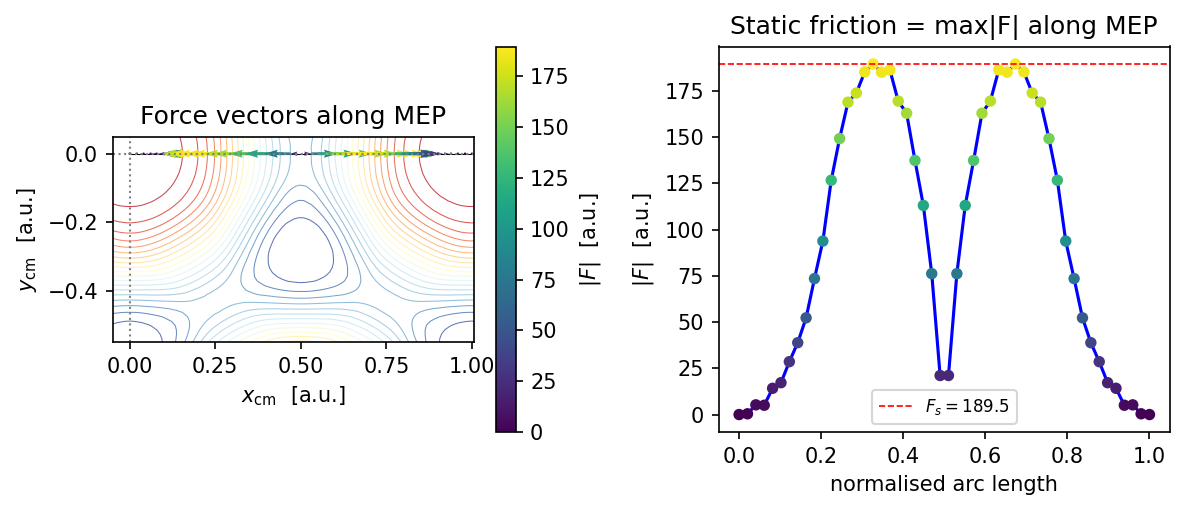

In [8]:
grad  = -mep['gradient']           # (n_pt, 2): force at each path point
Fpath = np.linalg.norm(grad, axis=1)
print('Static friction Fs = max|F| = %.5g' % Fpath.max())

fig, (axE, axpath) = plt.subplots(1, 2, dpi=150, figsize=(8, 3.5))

axE.contour(xx_g, yy_g, zz_g, levels=20, cmap='RdYlBu_r', linewidths=0.5, alpha=0.8)
axE.plot(pts[:, 0], pts[:, 1], '-k', lw=0.5, zorder=1)
qv = axE.quiver(pts[:, 0], pts[:, 1],
                grad[:, 0], grad[:, 1], Fpath,
                angles='xy', scale_units='xy', scale=1e3,
                zorder=2, cmap='viridis')
plt.colorbar(qv, ax=axE, label=r'$|F|$  [a.u.]')
plt_cosmetic(axE)
axE.set_xlim([-0.05, 1.005])
axE.set_ylim([-0.55, 0.05])
axE.set_xlabel(r'$x_\mathrm{cm}$  [a.u.]')
axE.set_ylabel(r'$y_\mathrm{cm}$  [a.u.]')
axE.set_title('Force vectors along MEP')

axpath.plot(s, Fpath, '-b')
axpath.scatter(s, Fpath, c=Fpath, cmap='viridis', s=20, zorder=2)
axpath.axhline(Fpath.max(), ls='--', color='red', lw=0.8,
               label=r'$F_s = %.4g$' % Fpath.max())
axpath.set_xlabel('normalised arc length')
axpath.set_ylabel(r'$|F|$  [a.u.]')
axpath.set_title('Static friction = max|F| along MEP')
axpath.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3D roto-translational MEP
  
  Here the configuration space is 3D: $(x_\text{cm}, y_\text{cm}, \theta)$.
  The string method finds the MEP in this space, so both translation and
  rotation are free to relax simultaneously.
  
### Scaled arc-length metric
  
  The three coordinates have different units (length vs. degrees), so we
  rescale them before computing arc lengths: 
  
  $$ds^2 = \left(\frac{dx}{l_x}\right)^2 + \left(\frac{dy}{l_y}\right)^2 + \left(\frac{d\theta}{l_\theta}\right)^2$$
  
  Here $l_x = l_y = 1$ (substrate lattice spacing) and $l_\theta = 60°$
  (the angular period for commensurate triangular-on-triangular contact).
  With this metric all three degrees of freedom contribute equally to the path length.
  
  > **Important:** for `find_mep` with `dim=3`, `pos` **must** be in the reference frame
  > ($\theta = 0$, CM at origin). The string method applies rotation internally
  > at each path point. Do **not** pre-rotate `pos` before calling.



In [9]:
# Commensurate system: sinusoidal triangular substrate, small cluster.
ks = get_ks(1, 3, 4./3., 0.)   # triangular wave vectors
params_comm = {
    'sub_basis': [[0, 0]],
    'epsilon': 1,
    'well_shape': 'sin',
    'ks': ks,
    'a1': np.array([1.,   0.]),
    'a2': np.array([1./2., -sqrt(3.)/2.]),
    'cl_basis': [[0, 0]],
    'cluster_shape': 'circle',
    'N1': 9, 'N2': 9,   # small cluster for speed
    'theta': 0.0, 'pos_cm': [0, 0],
}

pen_func_c, en_func_c, en_inputs_c = substrate_from_params(params_comm)
pos_c = cluster_from_params(params_comm)
N_c = pos_c.shape[0]
print('Commensurate cluster N=%i' % N_c)

Commensurate cluster N=85


### Sanity check: rotational period

Before computing the 3D MEP, verify that the angular period is 60 deg
as expected for triangular-on-triangular contact.

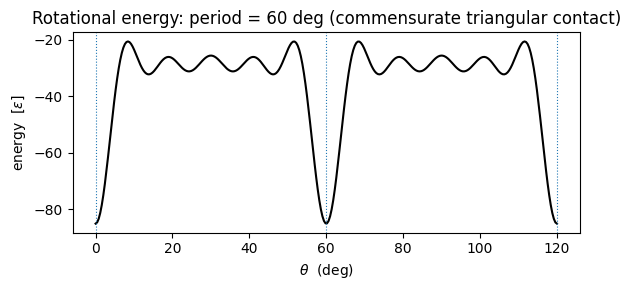

In [10]:
theta_vals = np.linspace(0, 120, 300)   # two full periods
rot_result = rotational_map(pos_c, en_func_c, en_inputs_c,
                            theta_deg=theta_vals, pos_cm=[0, 0])

fig, ax = plt.subplots(dpi=100, figsize=(6, 3))
ax.plot(theta_vals, rot_result['energy'], '-k')
for t0_v in [0, 60, 120]:
    ax.axvline(t0_v, ls=':', color='tab:blue', lw=0.8)
ax.set_xlabel(r'$\theta$  (deg)')
ax.set_ylabel(r'energy  [$\epsilon$]')
ax.set_title('Rotational energy: period = 60 deg (commensurate triangular contact)')
plt.tight_layout()
plt.show()

### Pure rotational MEP ($\theta: 0 \to 60°$)
  
  The cluster starts at $\theta = 0$ and rotates to the next equivalent minimum
  at $\theta = 60°$. The barrier in this 1D scan gives the rotational depinning torque.


In [11]:
p0_3d = [0.0, 0.0,  0.0]   # x_cm, y_cm, theta [deg]
p1_3d = [0.0, 0.0, 60.0]   # next equivalent minimum (pure rotation)

# ltheta = 60 deg makes the angular coordinate dimensionally compatible
# with the translational ones (both scaled to O(1)).
ltheta = 60.0
scale_3d = [1.0, 1.0, ltheta]

t0 = time()
mep3 = find_mep(
    pos_c, en_func_c, en_inputs_c,   # reference-frame pos -- NOT pre-rotated
    p0=p0_3d, p1=p1_3d,
    n_pt=200, max_steps=5000, dt=1e-3,
    fix_ends=True, tol=1e-2,
    scale=scale_3d,
)
te = time() - t0
print('3D MEP done: %is  converged=%s  steps=%i'
      % (te, mep3['converged'], mep3['n_steps']))
print('Rotational barrier: %.5g' % mep3['barrier'])

pts3  = mep3['points']     # (n_pt, 3): x_cm, y_cm, theta_deg
en3   = mep3['energy']
grad3 = mep3['gradient']   # (n_pt, 3): Fx, Fy, tau
s3    = np.linspace(0, 1, len(pts3))

3D MEP done: 0s  converged=True  steps=1
Rotational barrier: 64.326


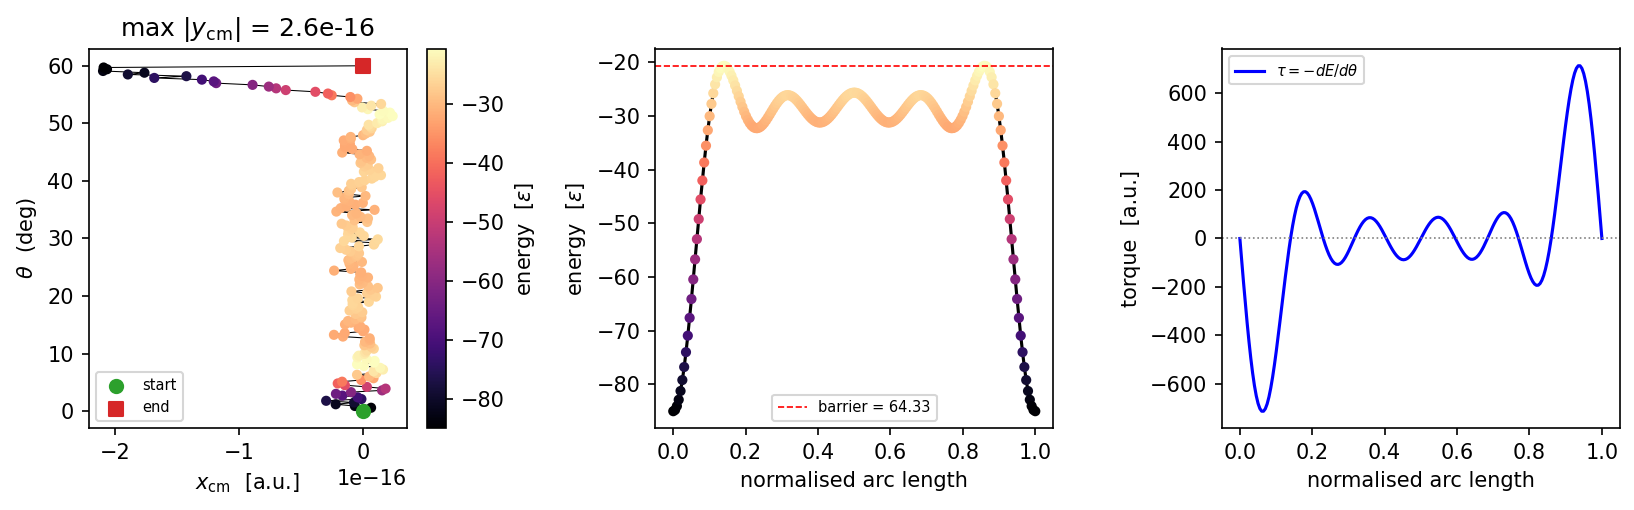

In [12]:
fig, axes = plt.subplots(1, 3, dpi=150, figsize=(11, 3.5))
ax_xt, ax_en, ax_tau = axes

# Path in (x_cm, theta) space, coloured by energy.
# y_cm should remain ~0 by symmetry for this pure-rotation path.
sc = ax_xt.scatter(pts3[:, 0], pts3[:, 2], c=en3, cmap='magma', s=15, zorder=3)
ax_xt.plot(pts3[:, 0], pts3[:, 2], '-k', lw=0.5, zorder=2)
ax_xt.scatter([p0_3d[0]], [p0_3d[2]], marker='o', color='tab:green', s=40, zorder=4, label='start')
ax_xt.scatter([p1_3d[0]], [p1_3d[2]], marker='s', color='tab:red',   s=40, zorder=4, label='end')
plt.colorbar(sc, ax=ax_xt, label=r'energy  [$\epsilon$]')
ax_xt.set_xlabel(r'$x_\mathrm{cm}$  [a.u.]')
ax_xt.set_ylabel(r'$\theta$  (deg)')
ax_xt.set_title(r'max $|y_\mathrm{cm}|$ = %.2g' % np.abs(pts3[:, 1]).max())
ax_xt.legend(fontsize=7)

# Energy profile.
ax_en.plot(s3, en3, '-k')
ax_en.scatter(s3, en3, c=en3, cmap='magma', s=15, zorder=2)
ax_en.axhline(en3.max(), ls='--', color='red', lw=0.8,
              label='barrier = %.4g' % mep3['barrier'])
ax_en.set_xlabel('normalised arc length')
ax_en.set_ylabel(r'energy  [$\epsilon$]')
ax_en.legend(fontsize=7)

# Torque along path: tau = -dE/dtheta drives the rotation.
ax_tau.plot(s3, grad3[:, 2], '-b', label=r'$\tau = -dE/d\theta$')
ax_tau.axhline(0, ls=':', color='gray', lw=0.8)
ax_tau.set_xlabel('normalised arc length')
ax_tau.set_ylabel(r'torque  [a.u.]')
ax_tau.legend(fontsize=7)

plt.tight_layout()
plt.show()

### Roto-translational MEP ($x_\text{cm}: 0 \to 1$, $\theta: 0 \to 60°$)
  
  A more physically rich path: the cluster translates by one lattice vector
  **and** rotates to the next commensurate orientation simultaneously.
  This is the typical depinning trajectory when both translational and
  rotational degrees of freedom are active — the kind of motion observed
  in Moiré heterostructure experiments.


In [13]:
p0_rt = [0.0, 0.0,  0.0]
p1_rt = [1.0, 0.0, 60.0]   # one lattice step in x + one angular period

t0 = time()
mep_rt = find_mep(
    pos_c, en_func_c, en_inputs_c,
    p0=p0_rt, p1=p1_rt,
    n_pt=200, max_steps=1000, dt=1e-3,
    fix_ends=True, tol=1e-4,
    scale=scale_3d,
)
te = time() - t0
print('Roto-translational MEP: %is  converged=%s  barrier=%.5g'
      % (te, mep_rt['converged'], mep_rt['barrier']))

pts_rt  = mep_rt['points']
en_rt   = mep_rt['energy']
grad_rt = mep_rt['gradient']
s_rt    = np.linspace(0, 1, len(pts_rt))

Roto-translational MEP: 11s  converged=False  barrier=56.667


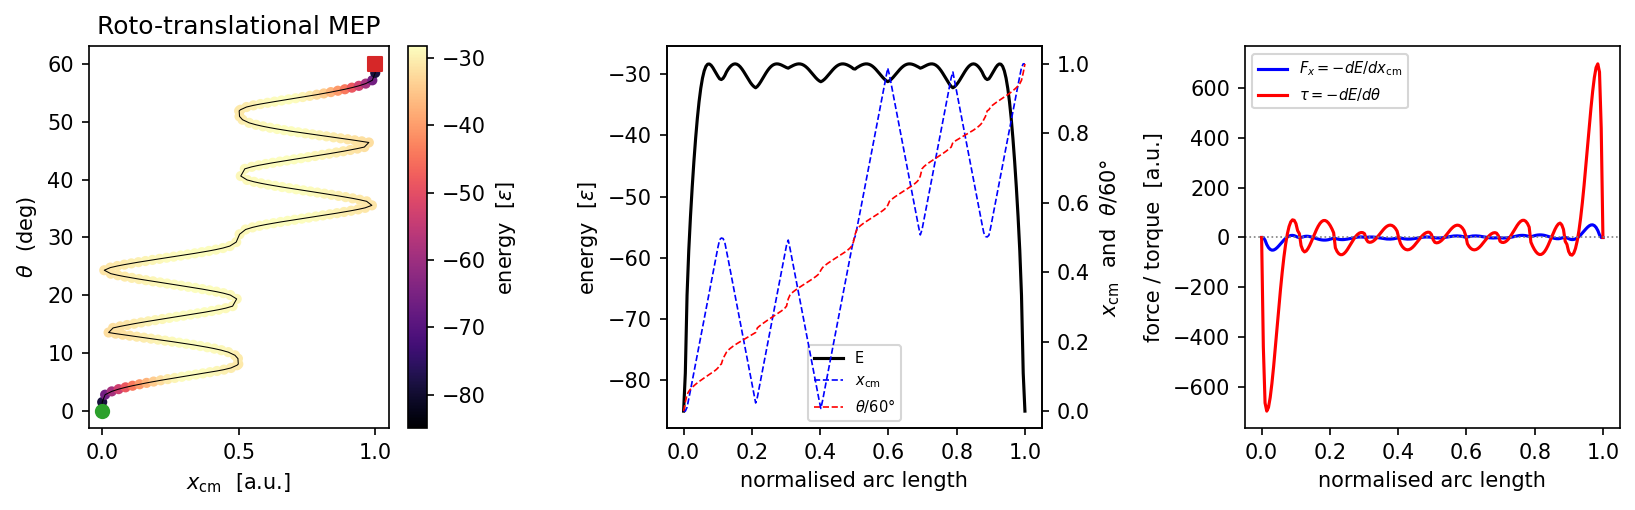

In [14]:
fig, axes = plt.subplots(1, 3, dpi=150, figsize=(11, 3.5))
ax_xt, ax_en, ax_fg = axes

sc = ax_xt.scatter(pts_rt[:, 0], pts_rt[:, 2], c=en_rt, cmap='magma', s=15)
ax_xt.plot(pts_rt[:, 0], pts_rt[:, 2], '-k', lw=0.5)
ax_xt.scatter([p0_rt[0]], [p0_rt[2]], marker='o', color='tab:green', s=40, zorder=4)
ax_xt.scatter([p1_rt[0]], [p1_rt[2]], marker='s', color='tab:red',   s=40, zorder=4)
plt.colorbar(sc, ax=ax_xt, label=r'energy  [$\epsilon$]')
ax_xt.set_xlabel(r'$x_\mathrm{cm}$  [a.u.]')
ax_xt.set_ylabel(r'$\theta$  (deg)')
ax_xt.set_title('Roto-translational MEP')

# Energy + x_cm + theta along path (on twin axes for scale).
ax_en.plot(s_rt, en_rt, '-k', label='E')
axt2 = ax_en.twinx()
axt2.plot(s_rt, pts_rt[:, 0],        '--b', lw=0.8, label=r'$x_\mathrm{cm}$')
axt2.plot(s_rt, pts_rt[:, 2]/ltheta, '--r', lw=0.8, label=r'$\theta/60°$')
axt2.set_ylabel(r'$x_\mathrm{cm}$  and  $\theta/60°$')
lines1, labs1 = ax_en.get_legend_handles_labels()
lines2, labs2 = axt2.get_legend_handles_labels()
ax_en.legend(lines1+lines2, labs1+labs2, fontsize=7)
ax_en.set_xlabel('normalised arc length')
ax_en.set_ylabel(r'energy  [$\epsilon$]')

# Fx and tau along path -- show what drives each degree of freedom.
ax_fg.plot(s_rt, grad_rt[:, 0], '-b', label=r'$F_x = -dE/dx_\mathrm{cm}$')
ax_fg.plot(s_rt, grad_rt[:, 2], '-r', label=r'$\tau = -dE/d\theta$')
ax_fg.axhline(0, ls=':', color='gray', lw=0.8)
ax_fg.set_xlabel('normalised arc length')
ax_fg.set_ylabel('force / torque  [a.u.]')
ax_fg.legend(fontsize=7)

plt.tight_layout()
plt.show()